Data type: uint8
Min. value: 0
Max value: 255


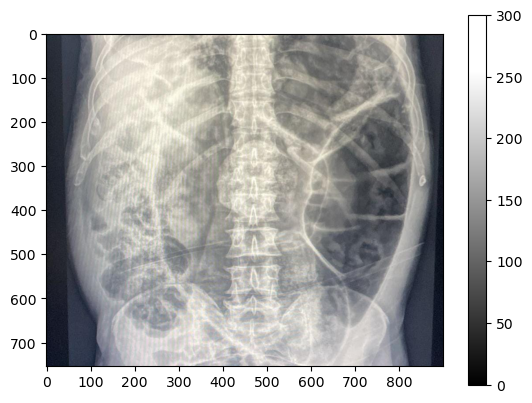

In [5]:
# 1. Importamos las librerías necesarias
import imageio.v2 as imageio  # lector de imágenes
import numpy as np  # operaciones numéricas
import matplotlib.pyplot as plt  # visualización

# 2. Cargamos la imagen radiologica
im = imageio.imread('RXTorax.jpeg')

# 3. Mostramos información básica de la imagen
print('Data type:', im.dtype)
print('Min. value:', im.min())
print('Max value:', im.max())

# 4. Configuramos los valores de ticks (intervalos para la barra de color)
import matplotlib.ticker as ticker
min_val = 0
max_val = np.max(im)
tick_interval = 50
tick_vals = np.arange(min_val, int(max_val) + tick_interval, tick_interval)

# Mostrar la imagen en escala de grises
plt.imshow(im, vmin=0, vmax=255, cmap='gray')
colorbar = plt.colorbar()
colorbar.set_ticks(tick_vals)

# Renderizar la figura
plt.show()

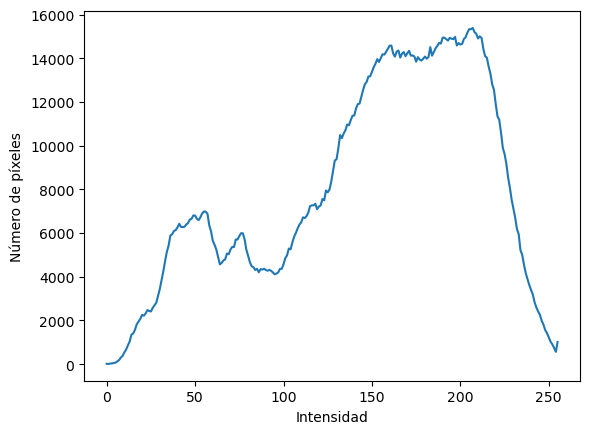

In [7]:
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi
# Create a histogram, binned at each possible value
hist = ndi.histogram(im, min=0, max=255, bins=256)
hist.shape
# Dibujar el Histograma
plt.plot(hist)
plt.xlabel('Intensidad')
plt.ylabel('Número de píxeles')
plt.show()

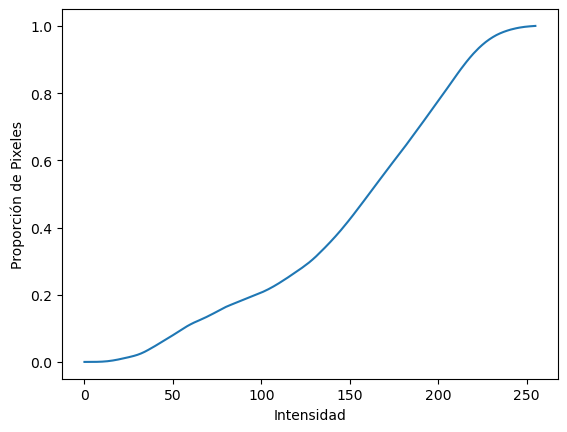

6

In [8]:
# Create a cumulative distribution function
cdf = hist.cumsum() / hist.sum()
cdf.shape
# Dibujar distribución CDF
plt.plot(cdf)
plt.xlabel('Intensidad')
plt.ylabel('Proporción de Pixeles')
plt.show()
6


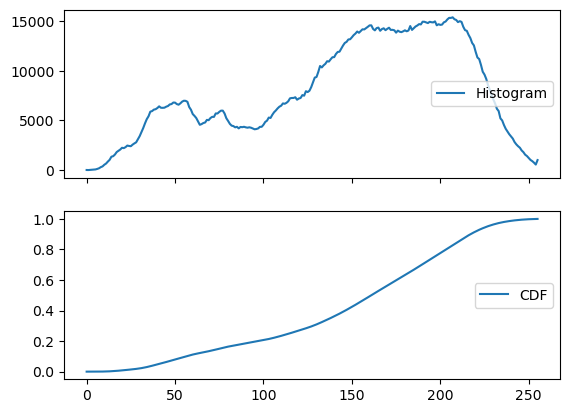

In [12]:
# Plot the histogram and CDF
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(hist, label='Histogram')
axes[1].plot(cdf, label='CDF')
for ax in fig.axes:
    ax.legend(loc='center right')
plt.show()

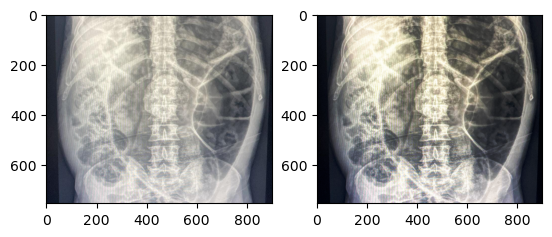

In [13]:
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(im)
axes[1].imshow(im_ecualizada)
plt.show()


In [16]:
import numpy as np
im = np.array([[10, 20, 80],
            [30, 60, 90],
            [15, 25, 40]])
mask = im > 50
print(mask)

[[False False  True]
 [False  True  True]
 [False False False]]


In [15]:
mask_range = (im > 30) & (im < 80)
print(mask_range)

[[False False False]
 [False  True False]
 [False False  True]]


In [17]:
masked_im = np.where(mask, im, 0)
print(masked_im)

[[ 0  0 80]
 [ 0 60 90]
 [ 0  0  0]]


In [18]:
im_masked = im.copy()
im_masked[~mask] = 0 # ~ invierte la máscara (False → True)
print(masked_im)

[[ 0  0 80]
 [ 0 60 90]
 [ 0  0  0]]


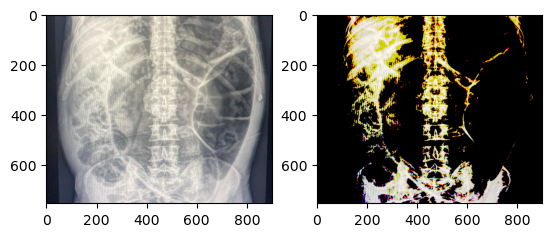

In [28]:
im = imageio.imread('RXTorax.jpeg')
bone_mask = im > 200
im_masked = im.copy()
im_masked[~bone_mask] = 0
fig, axes = plt.subplots(1, 2)
axes[0].imshow(im)
axes[1].imshow(im_masked, cmap='gray')
plt.show()

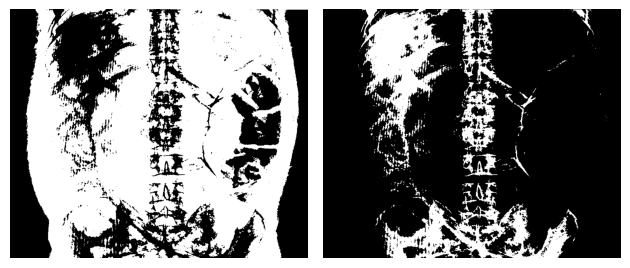

In [32]:
# 1. Importamos las librerías necesarias
import imageio.v2 as imageio # lector de imágenes
import numpy as np # operaciones numéricas
import matplotlib.pyplot as plt # visualización
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi
im = imageio.imread('RXTorax.jpeg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)
hist = ndi.histogram(im, min=0, max=255, bins=256)
cdf = hist.cumsum() / hist.sum()
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
# Create skin and bone masks
mask_skin = (im_ecualizada >= 50) & (im_ecualizada < 208)
mask_bone = im_ecualizada >=210
# Plot the skin (0) and bone (1) masks
fig, axes = plt.subplots(1,2)
axes[0].imshow(mask_skin, cmap='gray')
axes[1].imshow(mask_bone, cmap='gray')
for ax in fig.axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

La radiografia de cuerpo de un Neonato de 8 meses


Data type: uint8
Min. value: 0
Max value: 255


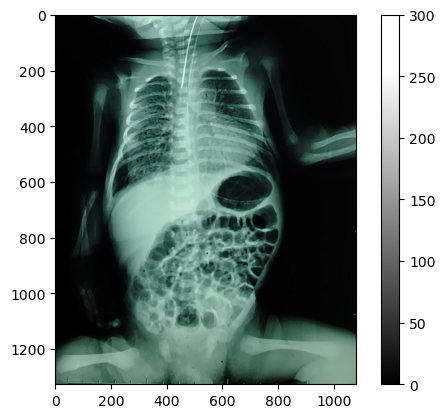

In [33]:
# 1. Importamos las librerías necesarias
import imageio.v2 as imageio  # lector de imágenes
import numpy as np  # operaciones numéricas
import matplotlib.pyplot as plt  # visualización

# 2. Cargamos la imagen radiologica
im = imageio.imread('RXNeonato.jpeg')

# 3. Mostramos información básica de la imagen
print('Data type:', im.dtype)
print('Min. value:', im.min())
print('Max value:', im.max())

# 4. Configuramos los valores de ticks (intervalos para la barra de color)
import matplotlib.ticker as ticker
min_val = 0
max_val = np.max(im)
tick_interval = 50
tick_vals = np.arange(min_val, int(max_val) + tick_interval, tick_interval)

# Mostrar la imagen en escala de grises
plt.imshow(im, vmin=0, vmax=255, cmap='gray')
colorbar = plt.colorbar()
colorbar.set_ticks(tick_vals)

# Renderizar la figura
plt.show()

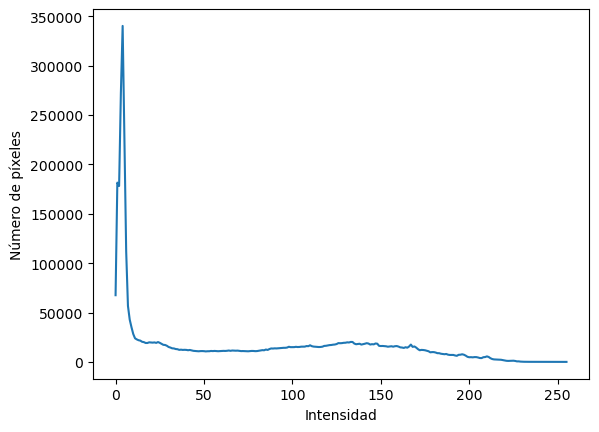

In [34]:
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi
# Create a histogram, binned at each possible value
hist = ndi.histogram(im, min=0, max=255, bins=256)
hist.shape
# Dibujar el Histograma
plt.plot(hist)
plt.xlabel('Intensidad')
plt.ylabel('Número de píxeles')
plt.show()


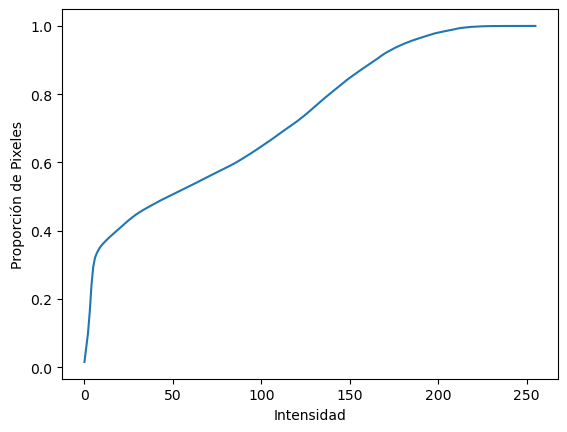

In [35]:
# Create a cumulative distribution function
cdf = hist.cumsum() / hist.sum()
cdf.shape
# Dibujar distribución CDF
plt.plot(cdf)
plt.xlabel('Intensidad')
plt.ylabel('Proporción de Pixeles')
plt.show()

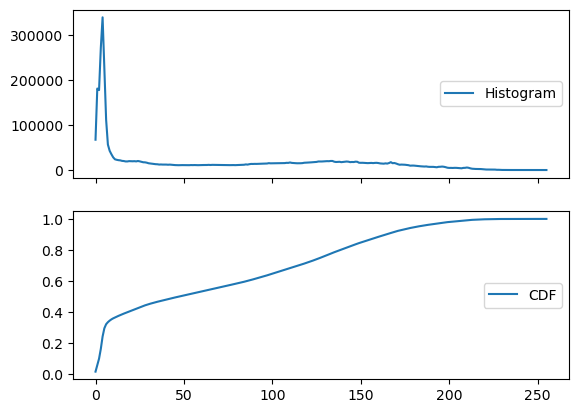

In [37]:
# Plot the histogram and CDF
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(hist, label='Histogram')
axes[1].plot(cdf, label='CDF')
for ax in fig.axes:
    ax.legend(loc='center right')
plt.show()

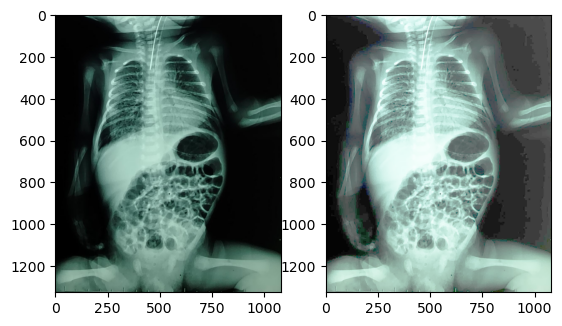

In [38]:
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(im)
axes[1].imshow(im_ecualizada)
plt.show()

In [39]:
import numpy as np
im = np.array([[10, 20, 80],
[30, 60, 90],
[15, 25, 40]])
mask = im > 50
print(mask)

[[False False  True]
 [False  True  True]
 [False False False]]


In [40]:
mask_range = (im > 30) & (im < 80)
print(mask_range)

[[False False False]
 [False  True False]
 [False False  True]]


In [41]:
masked_im = np.where(mask, im, 0)
print(masked_im)

[[ 0  0 80]
 [ 0 60 90]
 [ 0  0  0]]


In [42]:
im_masked = im.copy()
im_masked[~mask] = 0 # ~ invierte la máscara (False → True)
print(masked_im)

[[ 0  0 80]
 [ 0 60 90]
 [ 0  0  0]]


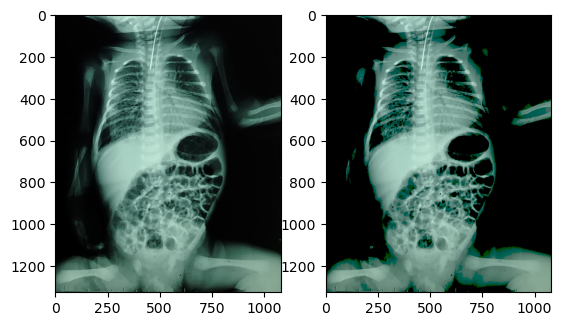

In [44]:
im = imageio.imread('RXNeonato.jpeg')
bone_mask = im > 64
im_masked = im.copy()
im_masked[~bone_mask] = 0
fig, axes = plt.subplots(1, 2)
axes[0].imshow(im)
axes[1].imshow(im_masked, cmap='gray')
plt.show()

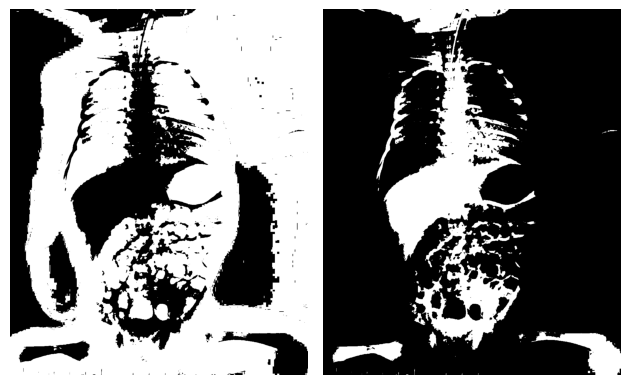

In [48]:
# 1. Importamos las librerías necesarias
import imageio.v2 as imageio # lector de imágenes
import numpy as np # operaciones numéricas
import matplotlib.pyplot as plt # visualización
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi
im = imageio.imread('RXNeonato.jpeg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)
hist = ndi.histogram(im, min=0, max=255, bins=256)
cdf = hist.cumsum() / hist.sum()
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
# Create skin and bone masks
mask_skin = (im_ecualizada >= 50) & (im_ecualizada < 208)
mask_bone = im_ecualizada >=210
# Plot the skin (0) and bone (1) masks
fig, axes = plt.subplots(1,2)
axes[0].imshow(mask_skin, cmap='gray')
axes[1].imshow(mask_bone, cmap='gray')
for ax in fig.axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

MEJORAR LA MASCARA Y FILTRO

In [49]:
# Importar librerías necesarias
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

In [50]:
# Cargar la imagen
im = imageio.imread('RXNeonato.jpeg')

# Convertir a escala de grises si es necesario
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)

# Mostrar información básica
print('Data type:', im.dtype)
print('Min. value:', im.min())
print('Max value:', im.max())
print('Shape:', im.shape)

Data type: uint8
Min. value: 0
Max value: 240
Shape: (1327, 1080)


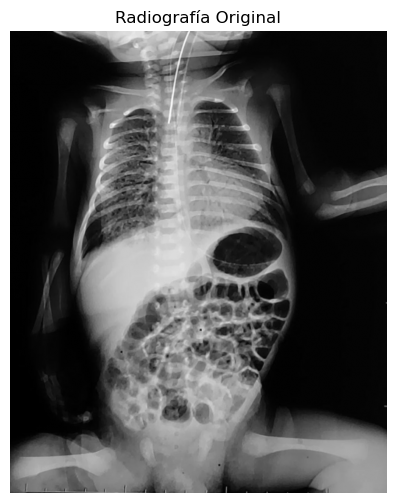

In [51]:
# Mostrar la imagen original
plt.figure(figsize=(8, 6))
plt.imshow(im, cmap='gray')
plt.title('Radiografía Original')
plt.axis('off')
plt.show()

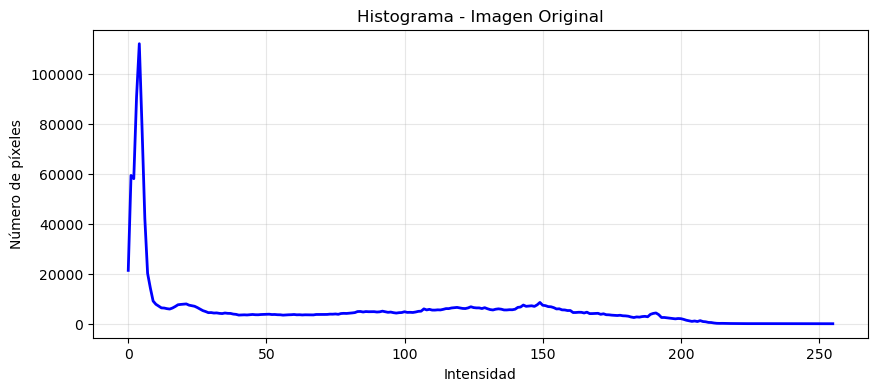

In [52]:
# Calcular histograma
hist = ndi.histogram(im, min=0, max=255, bins=256)

# Dibujar el histograma
plt.figure(figsize=(10, 4))
plt.plot(hist, color='blue', linewidth=2)
plt.xlabel('Intensidad')
plt.ylabel('Número de píxeles')
plt.title('Histograma - Imagen Original')
plt.grid(True, alpha=0.3)
plt.show()

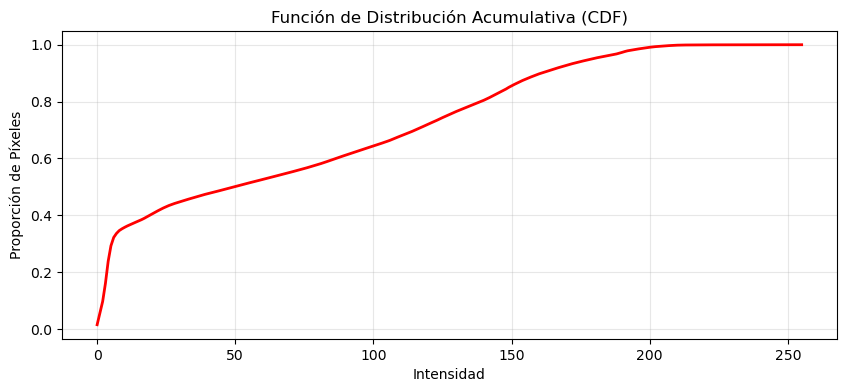

In [53]:
# Calcular CDF
cdf = hist.cumsum() / hist.sum()

# Visualizar CDF
plt.figure(figsize=(10, 4))
plt.plot(cdf, color='red', linewidth=2)
plt.xlabel('Intensidad')
plt.ylabel('Proporción de Píxeles')
plt.title('Función de Distribución Acumulativa (CDF)')
plt.grid(True, alpha=0.3)
plt.show()

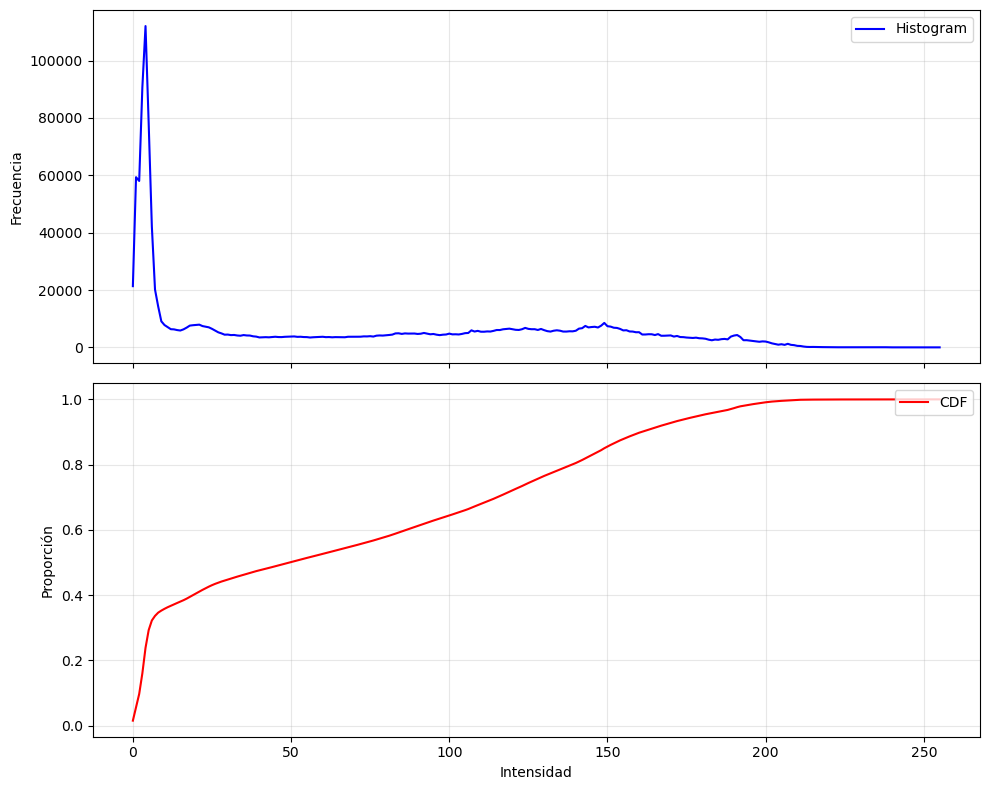

In [54]:
# Graficar histograma y CDF en subplots
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

axes[0].plot(hist, label='Histogram', color='blue')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cdf, label='CDF', color='red')
axes[1].set_xlabel('Intensidad')
axes[1].set_ylabel('Proporción')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
# Aplicar ecualización de histograma
im_ecualizada = (cdf[im] * 255).astype(np.uint8)

print("✓ Ecualización completada")
print(f"Rango original: {im.min()} - {im.max()}")
print(f"Rango ecualizado: {im_ecualizada.min()} - {im_ecualizada.max()}")

✓ Ecualización completada
Rango original: 0 - 240
Rango ecualizado: 3 - 255


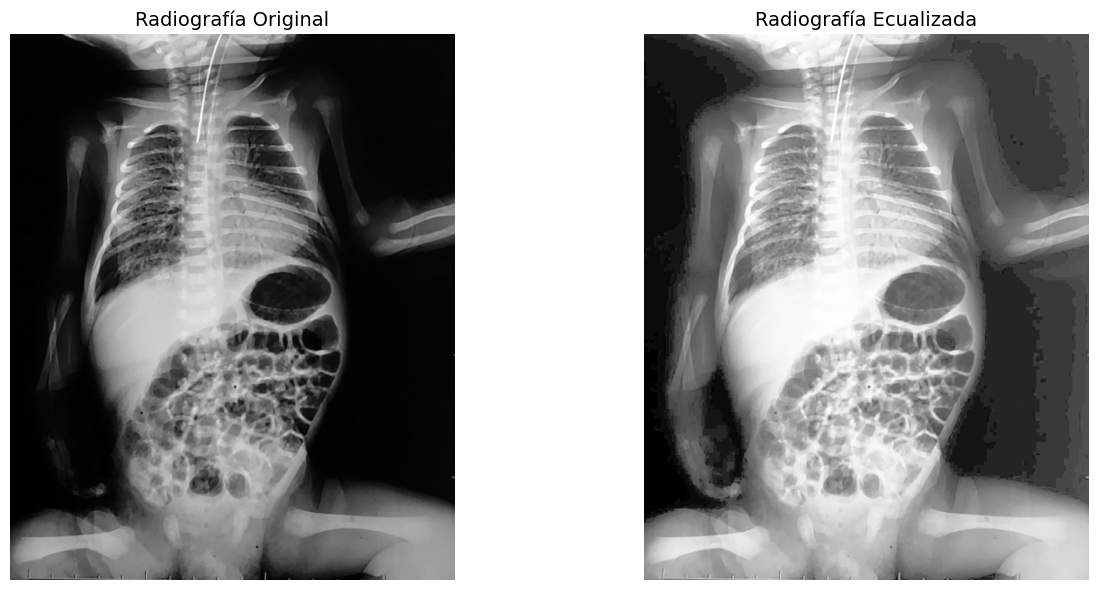

In [56]:
# Comparar imagen original y ecualizada
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(im, cmap='gray')
axes[0].set_title('Radiografía Original', fontsize=14)
axes[0].axis('off')

axes[1].imshow(im_ecualizada, cmap='gray')
axes[1].set_title('Radiografía Ecualizada', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

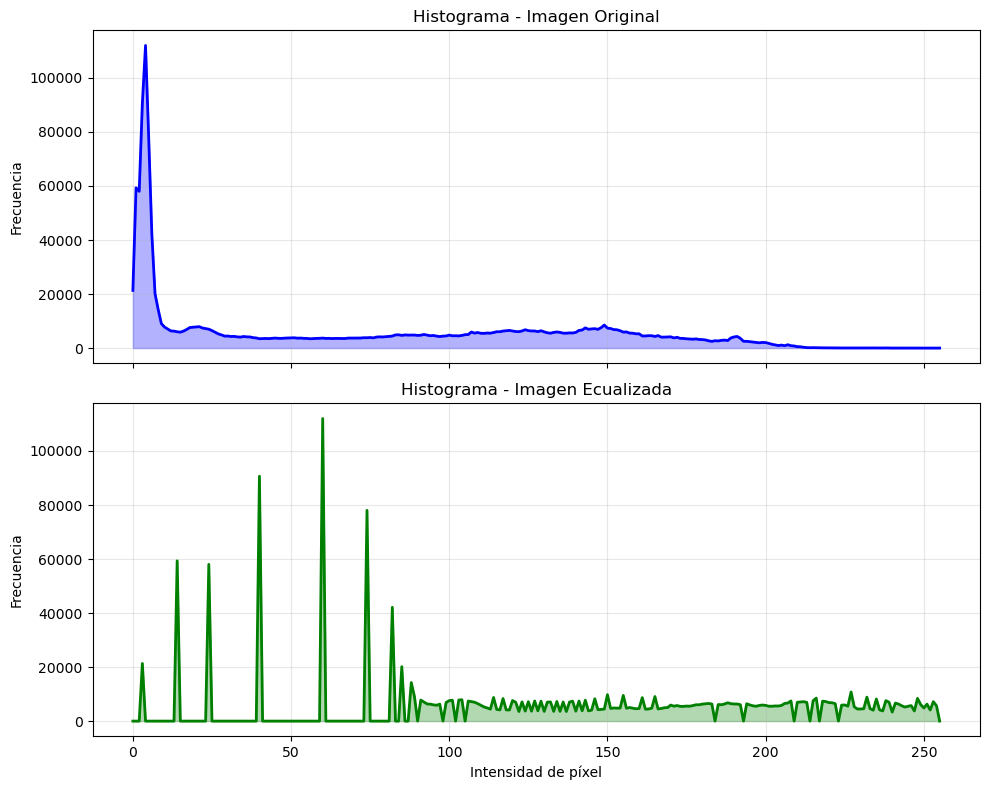

In [57]:
# Calcular histograma de la imagen ecualizada
hist_eq = ndi.histogram(im_ecualizada, min=0, max=255, bins=256)

# Comparar histogramas
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(hist, color='blue', linewidth=2)
axes[0].set_title('Histograma - Imagen Original')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(range(256), hist, alpha=0.3, color='blue')

axes[1].plot(hist_eq, color='green', linewidth=2)
axes[1].set_title('Histograma - Imagen Ecualizada')
axes[1].set_xlabel('Intensidad de píxel')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(range(256), hist_eq, alpha=0.3, color='green')

plt.tight_layout()
plt.show()

Ventana ajustada: 14 - 242


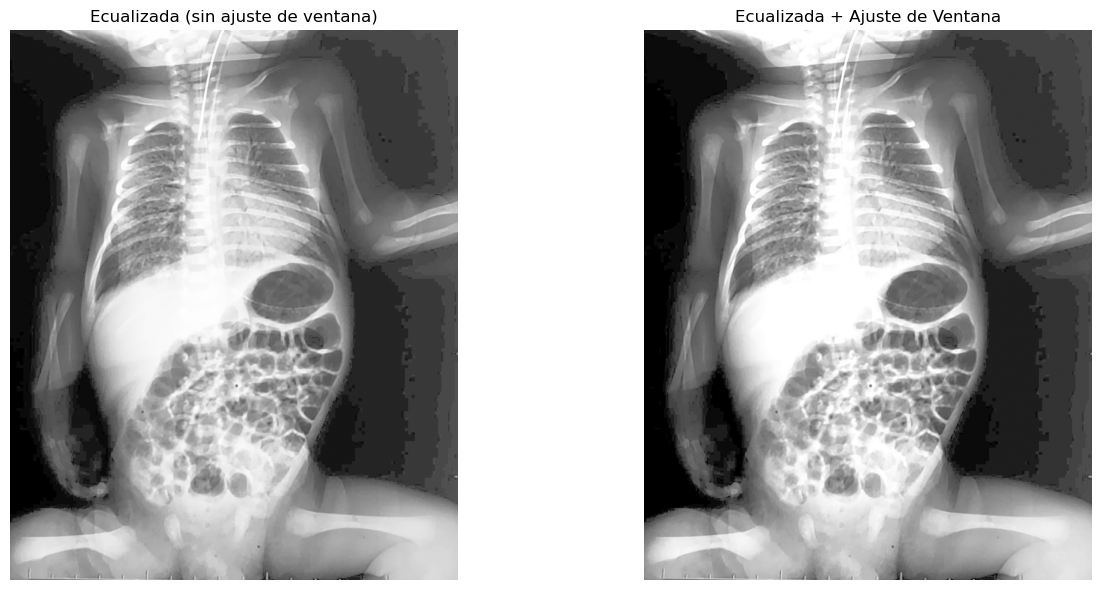

In [58]:
# Ajuste de ventana usando percentiles
vmin, vmax = np.percentile(im_ecualizada, [5, 95])

print(f"Ventana ajustada: {vmin:.0f} - {vmax:.0f}")

# Visualizar con ajuste de ventana
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(im_ecualizada, cmap='gray')
axes[0].set_title('Ecualizada (sin ajuste de ventana)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(im_ecualizada, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('Ecualizada + Ajuste de Ventana', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

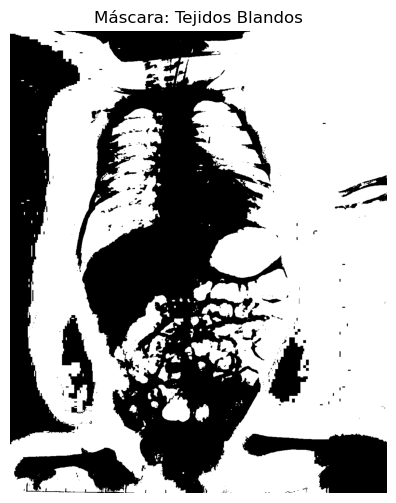

Píxeles de tejidos blandos: 869539


In [59]:
# Crear máscara para tejidos blandos (pulmones, órganos)
mask_tejidos = (im_ecualizada >= 30) & (im_ecualizada < 180)

# Visualizar máscara
plt.figure(figsize=(8, 6))
plt.imshow(mask_tejidos, cmap='gray')
plt.title('Máscara: Tejidos Blandos')
plt.axis('off')
plt.show()

print(f"Píxeles de tejidos blandos: {mask_tejidos.sum()}")

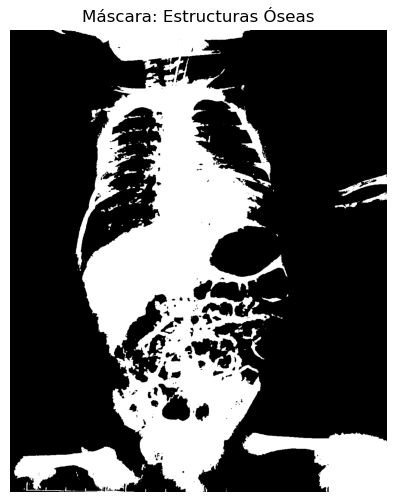

Píxeles de huesos: 424927


In [60]:
# Crear máscara para estructuras óseas densas
mask_huesos = im_ecualizada >= 180

# Visualizar máscara
plt.figure(figsize=(8, 6))
plt.imshow(mask_huesos, cmap='gray')
plt.title('Máscara: Estructuras Óseas')
plt.axis('off')
plt.show()

print(f"Píxeles de huesos: {mask_huesos.sum()}")

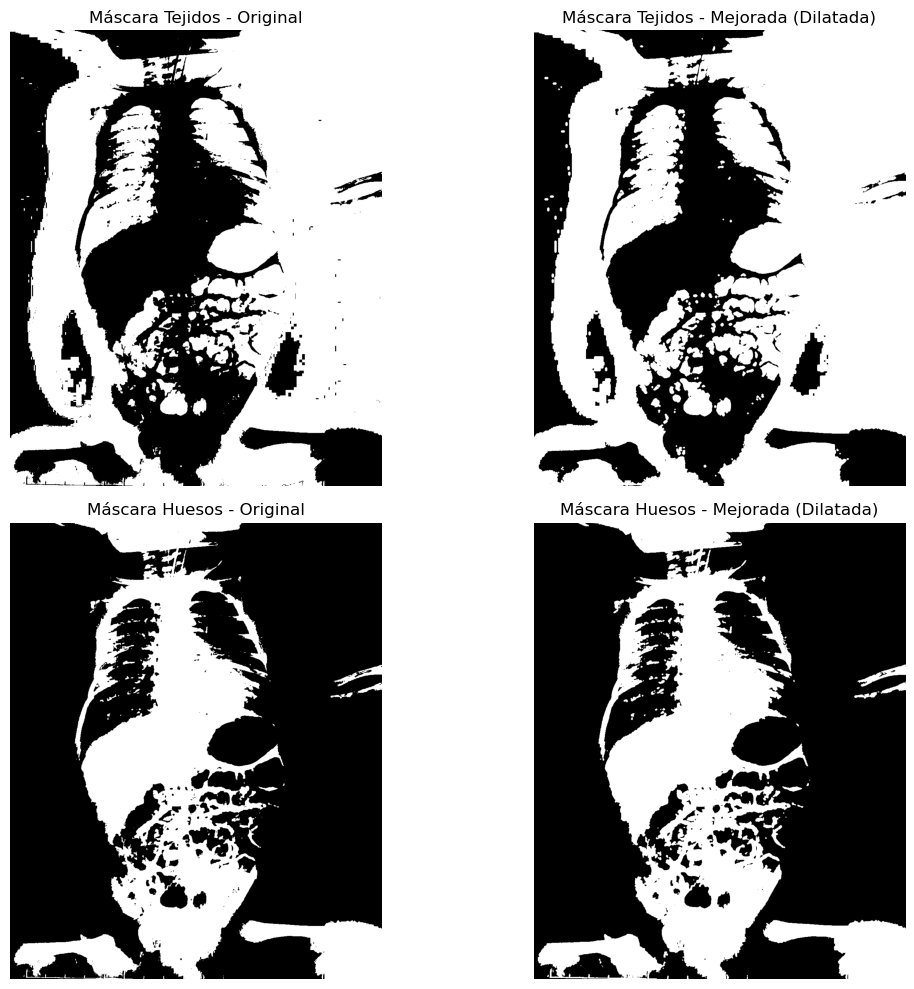

In [61]:
# Aplicar dilatación binaria para mejorar las máscaras
mask_tejidos_mejorada = ndi.binary_dilation(mask_tejidos, iterations=2)
mask_huesos_mejorada = ndi.binary_dilation(mask_huesos, iterations=1)

# Comparar máscaras originales y mejoradas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(mask_tejidos, cmap='gray')
axes[0, 0].set_title('Máscara Tejidos - Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(mask_tejidos_mejorada, cmap='gray')
axes[0, 1].set_title('Máscara Tejidos - Mejorada (Dilatada)')
axes[0, 1].axis('off')

axes[1, 0].imshow(mask_huesos, cmap='gray')
axes[1, 0].set_title('Máscara Huesos - Original')
axes[1, 0].axis('off')

axes[1, 1].imshow(mask_huesos_mejorada, cmap='gray')
axes[1, 1].set_title('Máscara Huesos - Mejorada (Dilatada)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

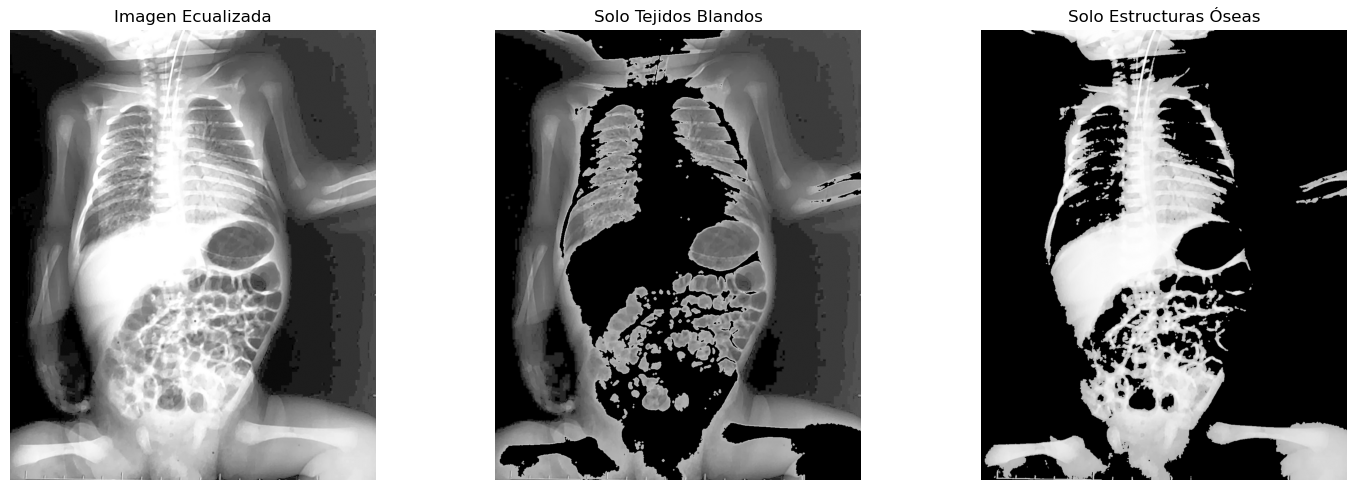

In [62]:
# Aplicar máscaras a la imagen ecualizada
im_tejidos = im_ecualizada.copy()
im_tejidos[~mask_tejidos_mejorada] = 0

im_huesos = im_ecualizada.copy()
im_huesos[~mask_huesos_mejorada] = 0

# Visualizar resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(im_ecualizada, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Imagen Ecualizada')
axes[0].axis('off')

axes[1].imshow(im_tejidos, cmap='gray')
axes[1].set_title('Solo Tejidos Blandos')
axes[1].axis('off')

axes[2].imshow(im_huesos, cmap='gray')
axes[2].set_title('Solo Estructuras Óseas')
axes[2].axis('off')

plt.tight_layout()
plt.show()

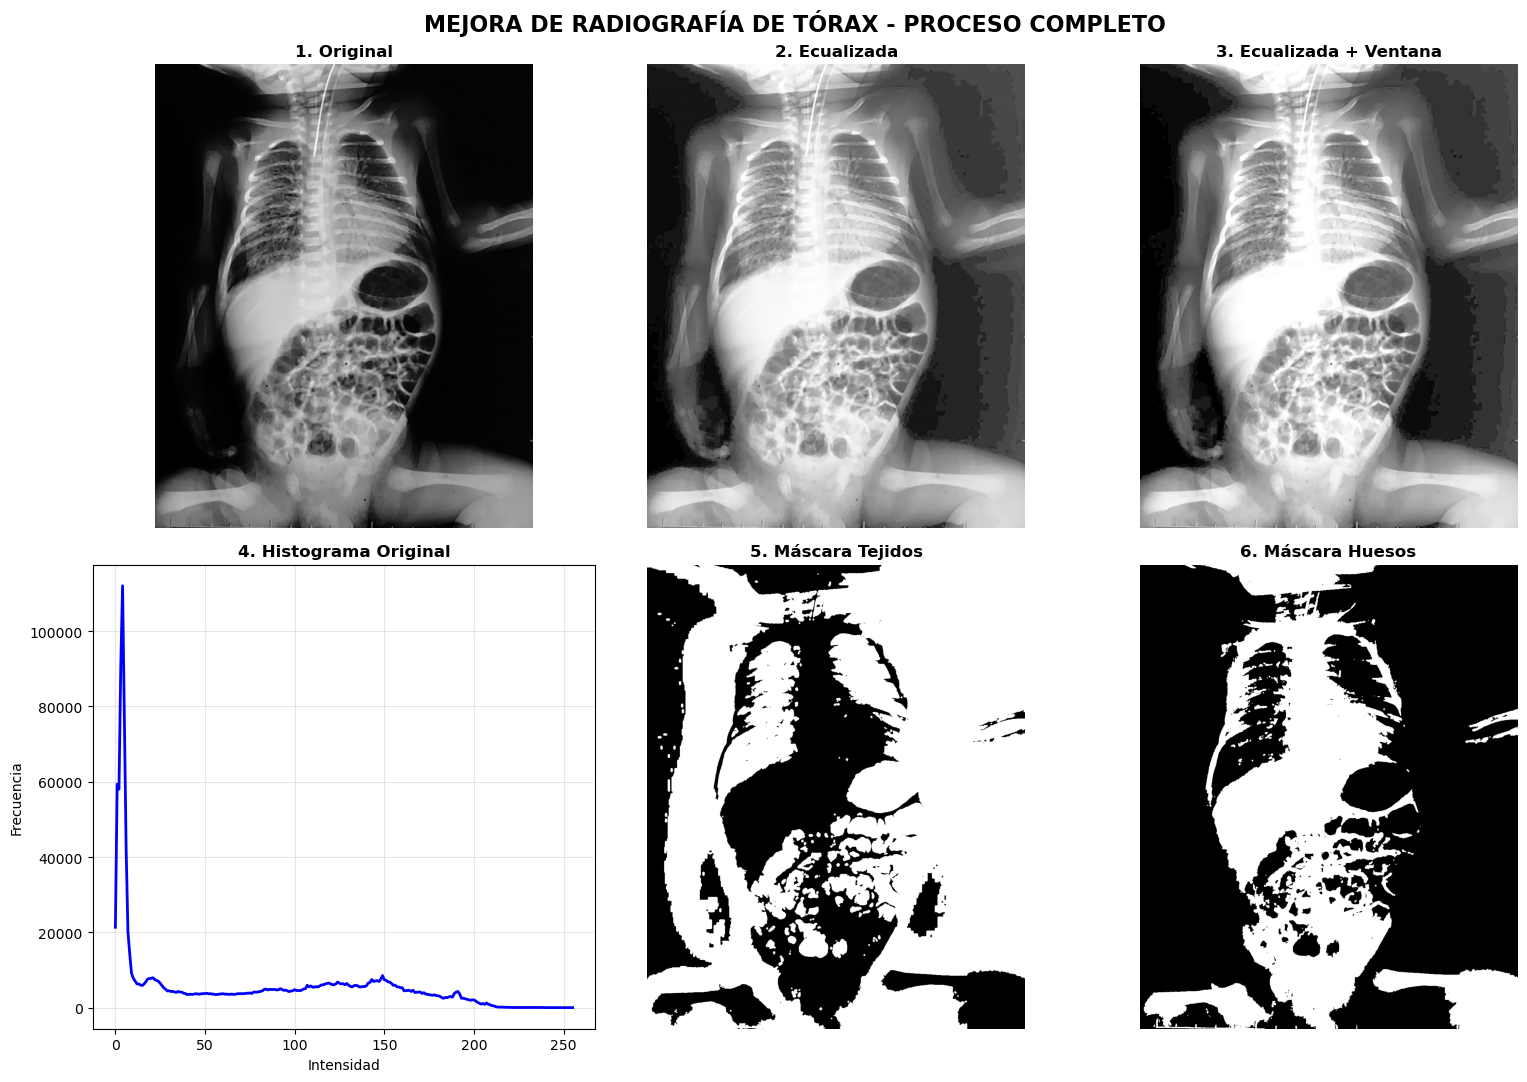

In [63]:
# Visualización final con todas las mejoras
fig, axes = plt.subplots(2, 3, figsize=(16, 11))

# Fila 1: Proceso de mejora
axes[0, 0].imshow(im, cmap='gray')
axes[0, 0].set_title('1. Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(im_ecualizada, cmap='gray')
axes[0, 1].set_title('2. Ecualizada', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(im_ecualizada, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 2].set_title('3. Ecualizada + Ventana', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Fila 2: Análisis con máscaras
axes[1, 0].plot(hist, color='blue', linewidth=2)
axes[1, 0].set_title('4. Histograma Original', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Intensidad')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].imshow(mask_tejidos_mejorada, cmap='gray')
axes[1, 1].set_title('5. Máscara Tejidos', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(mask_huesos_mejorada, cmap='gray')
axes[1, 2].set_title('6. Máscara Huesos', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('MEJORA DE RADIOGRAFÍA DE TÓRAX - PROCESO COMPLETO', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [64]:
# Mostrar estadísticas finales
print("=" * 60)
print("RESUMEN DEL PROCESAMIENTO")
print("=" * 60)
print(f"\n📊 IMAGEN ORIGINAL:")
print(f"   - Rango de intensidad: {im.min()} - {im.max()}")
print(f"   - Promedio: {im.mean():.2f}")
print(f"   - Desviación estándar: {im.std():.2f}")

print(f"\n📊 IMAGEN ECUALIZADA:")
print(f"   - Rango de intensidad: {im_ecualizada.min()} - {im_ecualizada.max()}")
print(f"   - Promedio: {im_ecualizada.mean():.2f}")
print(f"   - Desviación estándar: {im_ecualizada.std():.2f}")

print(f"\n📊 VENTANA AJUSTADA:")
print(f"   - Rango: {vmin:.0f} - {vmax:.0f}")

print(f"\n📊 SEGMENTACIÓN:")
print(f"   - Píxeles de tejidos blandos: {mask_tejidos_mejorada.sum():,}")
print(f"   - Píxeles de huesos: {mask_huesos_mejorada.sum():,}")
print(f"   - Total de píxeles: {im.size:,}")

print("\n✅ Procesamiento completado exitosamente")
print("=" * 60)

RESUMEN DEL PROCESAMIENTO

📊 IMAGEN ORIGINAL:
   - Rango de intensidad: 0 - 240
   - Promedio: 68.21
   - Desviación estándar: 64.72

📊 IMAGEN ECUALIZADA:
   - Rango de intensidad: 3 - 255
   - Promedio: 129.55
   - Desviación estándar: 71.27

📊 VENTANA AJUSTADA:
   - Rango: 14 - 242

📊 SEGMENTACIÓN:
   - Píxeles de tejidos blandos: 922,505
   - Píxeles de huesos: 447,855
   - Total de píxeles: 1,433,160

✅ Procesamiento completado exitosamente
